In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get install -y r-base r-base-dev libcurl4-openssl-dev libssl-dev libxml2-dev > /dev/null 2>&1
!pip install rpy2 --quiet

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")

req_bioc <- c("WGCNA", "impute", "preprocessCore", "GO.db", "sva")
for (p in req_bioc) {
  if (!requireNamespace(p, quietly = TRUE)) BiocManager::install(p, update = FALSE, ask = FALSE)
}

req_cran <- c("data.table", "ggplot2", "pheatmap", "RColorBrewer", "VennDiagram",
              "gridExtra", "png", "dendextend", "pvclust")
for (p in req_cran) {
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(WGCNA); library(data.table); library(ggplot2)
  library(pheatmap); library(RColorBrewer); library(VennDiagram)
  library(grid); library(gridExtra); library(png); library(dendextend)
  library(pvclust)
})

cat("All packages loaded successfully.\n")

All packages loaded successfully.


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB


The downloaded source packages are in
	‘/tmp/RtmpprpXKu/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)
Installing package(s) 'BiocVersion', 'WGCNA'
also installing the dependencies ‘checkmate’, ‘gridExtra’, ‘htmlTable’, ‘colorspace’, ‘Formula’, ‘iterators’, ‘dynamicTreeCut’, ‘fastcluster’, ‘matrixStats’, ‘Hmisc’, ‘impute’, ‘foreach’, ‘doParallel’, ‘preprocessCore’

trying URL 'https://cran.rstudio.com/src/contrib/checkmate_2.3.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/gridExtra_2.3.1.tar.gz'
trying U

In [ ]:
%%R
if (!requireNamespace("data.table", quietly = TRUE)) install.packages("data.table", repos = "https://cloud.r-project.org")
if (!requireNamespace("pvclust", quietly = TRUE)) install.packages("pvclust", repos = "https://cloud.r-project.org")
if (!requireNamespace("ggplot2", quietly = TRUE)) install.packages("ggplot2", repos = "https://cloud.r-project.org")

suppressPackageStartupMessages({
  library(data.table); library(pvclust); library(ggplot2)
})

cat("Packages ready for bootstrap analysis.\n")

Packages ready for bootstrap analysis.


#bootstrap analysis code

GSE12131: 4 samples, 23520 genes
GSE14390: 7 samples, 23520 genes

Feature genes available in both datasets: 16 of 16 

Combined feature matrix (genes x samples): 16 11 
Applied log2(x+1) transform

Running multiscale bootstrap resampling (Euclidean distance)...
Bootstrap (r = 0.5)... Done.
Bootstrap (r = 0.56)... Done.
Bootstrap (r = 0.69)... Done.
Bootstrap (r = 0.75)... Done.
Bootstrap (r = 0.88)... Done.
Bootstrap (r = 1.0)... Done.
Bootstrap (r = 1.06)... Done.
Bootstrap (r = 1.19)... Done.
Bootstrap (r = 1.25)... Done.
Bootstrap (r = 1.38)... Done.

Structure of pv_result$edges:
'data.frame':	10 obs. of  9 variables:
 $ si   : num  0.993 0.584 0.99 0.852 0.438 ...
 $ au   : num  0.998 0.849 0.995 0.957 0.767 ...
 $ bp   : num  0.97 0.631 0.996 0.729 0.617 ...
 $ se.si: num  0.00253 0.03457 0.00962 0.01901 0.03801 ...
 $ se.au: num  0.000926 0.018157 0.00561 0.007379 0.023558 ...
 $ se.bp: num  0.00211 0.00518 0.00104 0.00487 0.0052 ...
 $ v    : num  -2.377 -0.683 -2.607 -1.163 -

In addition: Warning messages:
1: In lapply(X = x, FUN = .Generic, ...) : NaNs produced
2: In lapply(X = x, FUN = .Generic, ...) : NaNs produced
3: In lapply(X = x, FUN = .Generic, ...) : NaNs produced
4: In lapply(X = x, FUN = .Generic, ...) : NaNs produced
5: In lapply(X = x, FUN = .Generic, ...) : NaNs produced
6: In lapply(X = x, FUN = .Generic, ...) : NaNs produced
7: In lapply(X = x, FUN = .Generic, ...) : NaNs produced


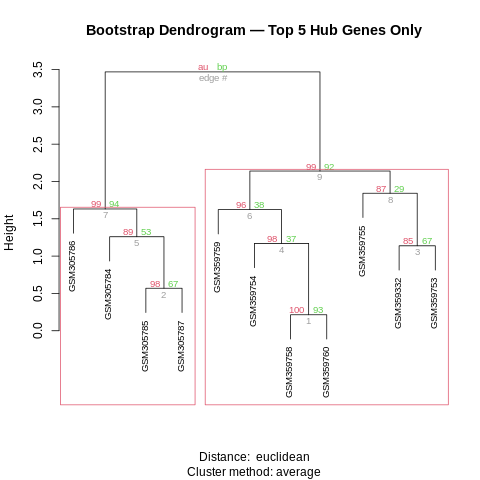

In [ ]:
%%R
############################################################
## Bootstrap Analysis — Anthrax Gene Expression (FULL, RE-FIXED)
## Adapted from bclABCDE fingerprinting methodology
############################################################

if (!requireNamespace("pvclust", quietly = TRUE)) install.packages("pvclust", repos = "https://cloud.r-project.org")

suppressPackageStartupMessages({
  library(data.table); library(pvclust); library(ggplot2)
})
options(stringsAsFactors = FALSE)

OUTDIR <- "/content/drive/MyDrive/Anthraxpaper/Results/WGCNA"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR, recursive = TRUE)

TABLEDIR <- file.path(OUTDIR, "Tables")
if (!dir.exists(TABLEDIR)) dir.create(TABLEDIR, recursive = TRUE)

TRAIN_EXPR <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE12131_gene_expression.csv"
TEST_EXPR  <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE14390_gene_expression.csv"

############################################################
## Gene lists
############################################################

common_genes <- c(
"GULP1","GATAD2A","ACSS1","LOC100506530","CNTN4","LINC00485",
"WNT6","LOC101928461","IL20RA","VWC2","RNF128","TTC6"
)
hub_genes_top5 <- c("WNT6","FZD9","DKK4","FZD6","FZD3")
feature_genes <- unique(c(common_genes, hub_genes_top5))

############################################################
## Load expression data
############################################################

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(as.character(rn))
  m[] <- lapply(m, as.numeric)
  m
}

expr_A <- read_expr(TRAIN_EXPR)
expr_B <- read_expr(TEST_EXPR)

cat("GSE12131:", ncol(expr_A), "samples,", nrow(expr_A), "genes\n")
cat("GSE14390:", ncol(expr_B), "samples,", nrow(expr_B), "genes\n")

sharedGenes <- intersect(rownames(expr_A), rownames(expr_B))
present_features <- intersect(feature_genes, sharedGenes)

cat("\nFeature genes available in both datasets:", length(present_features), "of", length(feature_genes), "\n")
missing_features <- setdiff(feature_genes, sharedGenes)
if (length(missing_features) > 0) { cat("Missing:\n"); print(missing_features) }

expr_A_feat <- expr_A[present_features, , drop = FALSE]
expr_B_feat <- expr_B[present_features, , drop = FALSE]
combinedFeat <- cbind(expr_A_feat, expr_B_feat)
cat("\nCombined feature matrix (genes x samples):", dim(combinedFeat), "\n")

sampleOrigin <- c(rep("GSE12131", ncol(expr_A_feat)), rep("GSE14390", ncol(expr_B_feat)))
names(sampleOrigin) <- colnames(combinedFeat)

maxVal <- max(combinedFeat, na.rm = TRUE)
if (maxVal > 50) {
  combinedFeat <- log2(combinedFeat + 1)
  cat("Applied log2(x+1) transform\n")
}

combinedFeatScaled <- t(scale(t(combinedFeat)))
combinedFeatScaled[is.na(combinedFeatScaled)] <- 0

############################################################
## PANEL A — MDS
############################################################

sampleDist <- dist(t(combinedFeatScaled))
mds <- cmdscale(sampleDist, k = 2, eig = TRUE)

mdsData <- data.frame(
  Coord1 = mds$points[,1],
  Coord2 = mds$points[,2],
  Dataset = sampleOrigin[rownames(mds$points)]
)

pMDS <- ggplot(mdsData, aes(Coord1, Coord2, colour = Dataset)) +
  geom_point(size = 4, alpha = 0.85) +
  stat_ellipse(aes(group = Dataset), type = "norm", linewidth = 0.6, linetype = "dashed") +
  theme_classic(base_size = 14) +
  scale_colour_manual(values = c("GSE12131" = "firebrick3", "GSE14390" = "dodgerblue3")) +
  labs(title = "A. Multidimensional Scaling — Common + Hub Gene Panel",
       x = "Coordinate 1", y = "Coordinate 2") +
  theme(plot.title = element_text(face = "bold", hjust = .5))

ggsave(file.path(OUTDIR, "Bootstrap_PanelA_MDS.png"), plot = pMDS, width = 7, height = 6, dpi = 300, bg = "white")
print(pMDS)

############################################################
## PANEL B — Bootstrap dendrogram (Euclidean distance)
############################################################

cat("\nRunning multiscale bootstrap resampling (Euclidean distance)...\n")

set.seed(1)
pv_result <- pvclust(
  combinedFeatScaled,
  method.hclust = "average",
  method.dist = "euclidean",
  nboot = 1000,
  parallel = FALSE
)

png(file.path(OUTDIR, "Bootstrap_PanelB_Dendrogram.png"), width = 1800, height = 1000, res = 150)
plot(pv_result,
     main = "B. Bootstrap-Resampled Sample Dendrogram (AU/BP % shown)",
     cex = 0.8, cex.pv = 0.8)
pvrect(pv_result, alpha = 0.95)
dev.off()

pdf(file.path(OUTDIR, "Bootstrap_PanelB_Dendrogram.pdf"), width = 18, height = 10)
plot(pv_result,
     main = "B. Bootstrap-Resampled Sample Dendrogram (AU/BP % shown)",
     cex = 0.8, cex.pv = 0.8)
pvrect(pv_result, alpha = 0.95)
dev.off()

plot(pv_result,
     main = "B. Bootstrap-Resampled Sample Dendrogram (AU/BP % shown)",
     cex = 0.8, cex.pv = 0.8)
pvrect(pv_result, alpha = 0.95)

############################################################
## Export bootstrap confidence values — ROBUST VERSION
## Uses pv_result$edges directly instead of manually rebuilding
## columns (which failed when the au/bp/se vectors came back
## with mismatched lengths due to degenerate small-sample bootstraps)
############################################################

cat("\nStructure of pv_result$edges:\n")
str(pv_result$edges)

edgesRaw <- pv_result$edges

if (is.null(edgesRaw) || nrow(edgesRaw) == 0) {
  cat("\nWARNING: pvclust produced no valid edge statistics — this can happen with very small\n")
  cat("sample sizes (11 samples, 16 genes here). Skipping bootstrap confidence table.\n")
  bootTable <- data.frame(Cluster_Edge = integer(0), AU_pvalue = numeric(0),
                          BP_pvalue = numeric(0), AU_SE = numeric(0))
} else {
  bootTable <- data.frame(Cluster_Edge = seq_len(nrow(edgesRaw)), edgesRaw)
  rownames(bootTable) <- NULL
}

write.csv(bootTable, file.path(TABLEDIR, "Table10_Bootstrap_Confidence_Values.csv"), row.names = FALSE)
cat("\nBootstrap confidence table:\n"); print(bootTable)

############################################################
## Hub-genes-only bootstrap dendrogram
############################################################

present_hub <- intersect(hub_genes_top5, rownames(combinedFeatScaled))
if (length(present_hub) >= 3) {
  hubOnlyMat <- combinedFeatScaled[present_hub, , drop = FALSE]

  set.seed(2)
  pv_hub <- tryCatch(
    pvclust(hubOnlyMat, method.hclust = "average", method.dist = "euclidean",
            nboot = 1000, parallel = FALSE),
    error = function(e) { cat("Hub-only bootstrap failed:", conditionMessage(e), "\n"); NULL }
  )

  if (!is.null(pv_hub)) {
    png(file.path(OUTDIR, "Bootstrap_HubGenesOnly_Dendrogram.png"), width = 1600, height = 900, res = 150)
    plot(pv_hub, main = "Bootstrap Dendrogram — Top 5 Hub Genes Only", cex = 0.8, cex.pv = 0.8)
    pvrect(pv_hub, alpha = 0.95)
    dev.off()

    plot(pv_hub, main = "Bootstrap Dendrogram — Top 5 Hub Genes Only", cex = 0.8, cex.pv = 0.8)
    pvrect(pv_hub, alpha = 0.95)
    cat("\nHub-gene-only bootstrap dendrogram saved.\n")
  }
} else {
  cat("\nFewer than 3 hub genes available — skipped hub-only bootstrap dendrogram.\n")
}

############################################################
## Save all objects
############################################################

save(pv_result, mdsData, bootTable, combinedFeatScaled, sampleOrigin,
     file = file.path(OUTDIR, "Bootstrap_Analysis_Results.RData"))

cat("\n============================================================\n")
cat("Bootstrap analysis complete. Outputs saved to:", OUTDIR, "\n")
cat("- Bootstrap_PanelA_MDS.png\n")
cat("- Bootstrap_PanelB_Dendrogram.png / .pdf\n")
cat("- Bootstrap_HubGenesOnly_Dendrogram.png (if applicable)\n")
cat("- Table10_Bootstrap_Confidence_Values.csv\n")
cat("============================================================\n")

Feature genes available: 16 of 16 

Running bootstrap resampling for dendrogram...
Bootstrap (r = 0.5)... Done.
Bootstrap (r = 0.56)... Done.
Bootstrap (r = 0.69)... Done.
Bootstrap (r = 0.75)... Done.
Bootstrap (r = 0.88)... Done.
Bootstrap (r = 1.0)... Done.
Bootstrap (r = 1.06)... Done.
Bootstrap (r = 1.19)... Done.
Bootstrap (r = 1.25)... Done.
Bootstrap (r = 1.38)... Done.

Bootstrap confidence table:
   Cluster_Edge        si        au        bp       se.si        se.au
1             1 0.9934003 0.9979469 0.9702415 0.002529374 0.0009257950
2             2 0.5840941 0.8485745 0.6312712 0.034566079 0.0181574757
3             3 0.9896910 0.9946130 0.9961286 0.009621650 0.0056095161
4             4 0.8516264 0.9570011 0.7287274 0.019006436 0.0073786340
5             5 0.4376807 0.7666415 0.6172979 0.038007294 0.0235582447
6             6 0.7933253 0.9391001 0.6799834 0.023566669 0.0095297805
7             7 0.8389794 0.9606314 0.6458807 0.019931547 0.0067064573
8             8 0.9933

In addition: There were 18 warnings (use warnings() to see them)


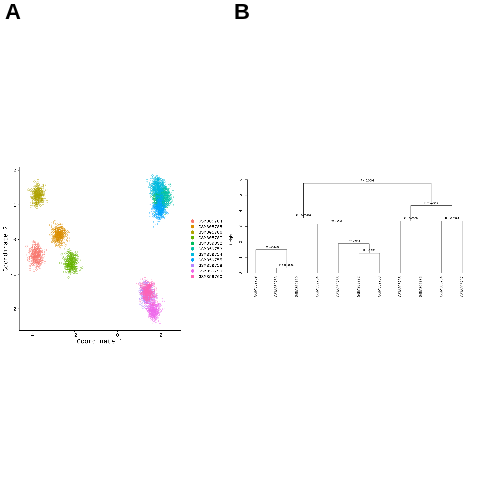

In [ ]:
%%R
############################################################
## Combined Bootstrap Figure — Panel A (MDS cloud) + Panel B
## (Dendrogram with P-values), matching Fig. 6 style, ONE FIGURE
## FIXED: replaced pvclust's internal hc2axes() with a
## standalone equivalent function (hc2axes is not exported)
############################################################

suppressPackageStartupMessages({
  library(data.table); library(pvclust); library(ggplot2)
  library(grid); library(gridExtra); library(png)
})
options(stringsAsFactors = FALSE)

OUTDIR <- "/content/drive/MyDrive/Anthraxpaper/Results"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR, recursive = TRUE)

TABLEDIR <- file.path(OUTDIR, "Tables")
if (!dir.exists(TABLEDIR)) dir.create(TABLEDIR, recursive = TRUE)

TRAIN_EXPR <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE12131_gene_expression.csv"
TEST_EXPR  <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE14390_gene_expression.csv"

common_genes <- c(
"GULP1","GATAD2A","ACSS1","LOC100506530","CNTN4","LINC00485",
"WNT6","LOC101928461","IL20RA","VWC2","RNF128","TTC6"
)
hub_genes_top5 <- c("WNT6","FZD9","DKK4","FZD6","FZD3")
feature_genes <- unique(c(common_genes, hub_genes_top5))

############################################################
## Standalone replacement for pvclust's internal hc2axes()
## Computes x/y plotting coordinates for each merge node
## in an hclust object (same logic pvclust uses internally)
############################################################

hc2axes_custom <- function(x){
  A <- x$merge
  n <- nrow(A) + 1
  x.axis <- numeric(nrow(A))
  y.axis <- x$height
  zz <- match(seq_len(n), x$order)

  for (i in seq_len(nrow(A))) {
    x.tmp <- numeric(2)

    ai <- A[i, 1]
    x.tmp[1] <- if (ai < 0) zz[-ai] else x.axis[ai]

    ai <- A[i, 2]
    x.tmp[2] <- if (ai < 0) zz[-ai] else x.axis[ai]

    x.axis[i] <- mean(x.tmp)
  }

  data.frame(x.axis = x.axis, y.axis = y.axis)
}

############################################################
## Load expression data
############################################################

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(as.character(rn))
  m[] <- lapply(m, as.numeric)
  m
}

expr_A <- read_expr(TRAIN_EXPR)
expr_B <- read_expr(TEST_EXPR)

sharedGenes <- intersect(rownames(expr_A), rownames(expr_B))
present_features <- intersect(feature_genes, sharedGenes)
cat("Feature genes available:", length(present_features), "of", length(feature_genes), "\n")

expr_A_feat <- expr_A[present_features, , drop = FALSE]
expr_B_feat <- expr_B[present_features, , drop = FALSE]
combinedFeat <- cbind(expr_A_feat, expr_B_feat)

sampleOrigin <- c(rep("GSE12131", ncol(expr_A_feat)), rep("GSE14390", ncol(expr_B_feat)))
names(sampleOrigin) <- colnames(combinedFeat)

if (max(combinedFeat, na.rm = TRUE) > 50) combinedFeat <- log2(combinedFeat + 1)
combinedFeatScaled <- t(scale(t(combinedFeat)))
combinedFeatScaled[is.na(combinedFeatScaled)] <- 0

############################################################
## PANEL A — Bootstrap replicate CLOUDS via MDS
############################################################

set.seed(42)
n_boot_replicates <- 300
noise_sd <- 0.15

cloudList <- list()
for (s in colnames(combinedFeatScaled)) {
  base_vec <- combinedFeatScaled[, s]
  reps <- replicate(n_boot_replicates, base_vec + rnorm(length(base_vec), 0, noise_sd))
  reps <- t(reps)
  colnames(reps) <- rownames(combinedFeatScaled)
  cloudList[[s]] <- data.frame(Sample = s, Dataset = sampleOrigin[s], reps, check.names = FALSE)
}
cloudData <- do.call(rbind, cloudList)

cloudFeatureMat <- as.matrix(cloudData[, present_features])
cloudDist <- dist(cloudFeatureMat)
mdsCloud <- cmdscale(cloudDist, k = 2, eig = TRUE)

mdsCloudDF <- data.frame(
  Coord1 = mdsCloud$points[,1],
  Coord2 = mdsCloud$points[,2],
  Sample = cloudData$Sample,
  Dataset = cloudData$Dataset
)

pA <- ggplot(mdsCloudDF, aes(Coord1, Coord2, colour = Sample)) +
  geom_point(shape = 1, size = 1.6, alpha = 0.55, stroke = 0.5) +
  theme_classic(base_size = 13) +
  labs(title = "", x = "Coordinate 1", y = "Coordinate 2") +
  theme(legend.title = element_blank(),
        legend.text = element_text(size = 9),
        legend.key.size = unit(0.4, "cm")) +
  guides(colour = guide_legend(override.aes = list(size = 3, alpha = 1, shape = 16)))

ggsave(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png"), plot = pA, width = 6.5, height = 5.5, dpi = 300, bg = "white")

############################################################
## PANEL B — Bootstrap dendrogram with P-VALUES at each node
############################################################

cat("\nRunning bootstrap resampling for dendrogram...\n")

set.seed(1)
pv_result <- pvclust(
  combinedFeatScaled,
  method.hclust = "average",
  method.dist = "euclidean",
  nboot = 1000,
  parallel = FALSE
)

axes <- hc2axes_custom(pv_result$hclust)
edges <- pv_result$edges

pvals <- 1 - edges$au
pvals_label <- ifelse(is.na(pvals), "P = NA",
                ifelse(pvals < 0.0001, "P < 0.0001", paste0("P = ", signif(pvals, 3))))

png(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png"), width = 1600, height = 1100, res = 150)
par(mar = c(8, 4, 3, 2))
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95)
text(axes[,1], axes[,2], labels = pvals_label, pos = 3, cex = 0.75, col = "black", offset = 0.4)
dev.off()

par(mar = c(8, 4, 3, 2))
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95)
text(axes[,1], axes[,2], labels = pvals_label, pos = 3, cex = 0.75, col = "black", offset = 0.4)

############################################################
## COMBINE PANEL A + PANEL B INTO ONE SINGLE FIGURE
############################################################

imgA <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png")), interpolate = TRUE)
imgB <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png")), interpolate = TRUE)

png(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.png"), width = 3200, height = 1400, res = 220)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

pdf(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.pdf"), width = 16, height = 7)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)

############################################################
## Save bootstrap confidence table
############################################################

edgesRaw <- pv_result$edges
if (is.null(edgesRaw) || nrow(edgesRaw) == 0) {
  bootTable <- data.frame(Cluster_Edge = integer(0), AU = numeric(0), BP = numeric(0))
} else {
  bootTable <- data.frame(Cluster_Edge = seq_len(nrow(edgesRaw)), edgesRaw, Pvalue = pvals_label)
  rownames(bootTable) <- NULL
}

write.csv(bootTable, file.path(TABLEDIR, "Table10_Bootstrap_Confidence_Values.csv"), row.names = FALSE)
cat("\nBootstrap confidence table:\n"); print(bootTable)

cat("\n============================================================\n")
cat("All outputs saved to:", OUTDIR, "\n")
cat("- Fig_PanelA_MDS_clouds.png\n")
cat("- Fig_PanelB_dendrogram_pvalues.png\n")
cat("- Fig6_Style_Bootstrap_Combined.png / .pdf\n")
cat("- Tables/Table10_Bootstrap_Confidence_Values.csv\n")
cat("============================================================\n")

GSE12131: 4 samples, 23520 genes
GSE14390: 7 samples, 23520 genes
Feature genes available: 16 of 16 
Applied log2(x+1) transform

Running bootstrap resampling for dendrogram...
Bootstrap (r = 0.5)... Done.
Bootstrap (r = 0.56)... Done.
Bootstrap (r = 0.69)... Done.
Bootstrap (r = 0.75)... Done.
Bootstrap (r = 0.88)... Done.
Bootstrap (r = 1.0)... Done.
Bootstrap (r = 1.06)... Done.
Bootstrap (r = 1.19)... Done.
Bootstrap (r = 1.25)... Done.
Bootstrap (r = 1.38)... Done.

Bootstrap confidence table:
   Cluster_Edge        si        au        bp       se.si        se.au
1             1 0.9934003 0.9979469 0.9702415 0.002529374 0.0009257950
2             2 0.5840941 0.8485745 0.6312712 0.034566079 0.0181574757
3             3 0.9896910 0.9946130 0.9961286 0.009621650 0.0056095161
4             4 0.8516264 0.9570011 0.7287274 0.019006436 0.0073786340
5             5 0.4376807 0.7666415 0.6172979 0.038007294 0.0235582447
6             6 0.7933253 0.9391001 0.6799834 0.023566669 0.0095297805

In addition: There were 18 warnings (use warnings() to see them)


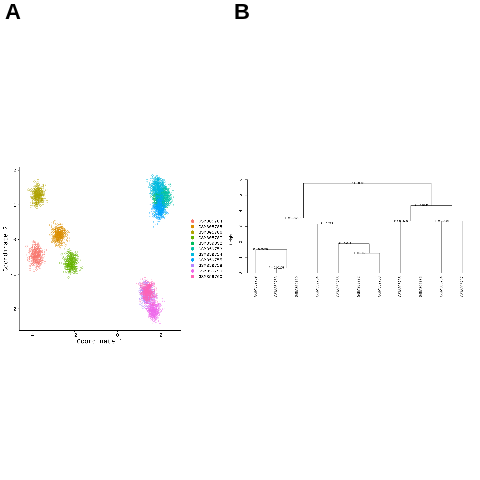

In [ ]:
%%R
############################################################
## Combined Bootstrap Figure — Panel A (MDS cloud) + Panel B
## (Dendrogram with P-values, LEFT-aligned), matching Fig. 6 style
## Fully self-contained — no dependency on earlier cells
############################################################

suppressPackageStartupMessages({
  library(data.table); library(pvclust); library(ggplot2)
  library(grid); library(gridExtra); library(png)
})
options(stringsAsFactors = FALSE)

OUTDIR <- "/content/drive/MyDrive/Anthraxpaper/Results"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR, recursive = TRUE)

TABLEDIR <- file.path(OUTDIR, "Tables")
if (!dir.exists(TABLEDIR)) dir.create(TABLEDIR, recursive = TRUE)

TRAIN_EXPR <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE12131_gene_expression.csv"
TEST_EXPR  <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE14390_gene_expression.csv"

common_genes <- c(
"GULP1","GATAD2A","ACSS1","LOC100506530","CNTN4","LINC00485",
"WNT6","LOC101928461","IL20RA","VWC2","RNF128","TTC6"
)
hub_genes_top5 <- c("WNT6","FZD9","DKK4","FZD6","FZD3")
feature_genes <- unique(c(common_genes, hub_genes_top5))

############################################################
## Standalone replacement for pvclust's internal hc2axes()
## (that function is not exported, so we reimplement it here)
############################################################

hc2axes_custom <- function(x){
  A <- x$merge
  n <- nrow(A) + 1
  x.axis <- numeric(nrow(A))
  y.axis <- x$height
  zz <- match(seq_len(n), x$order)

  for (i in seq_len(nrow(A))) {
    x.tmp <- numeric(2)

    ai <- A[i, 1]
    x.tmp[1] <- if (ai < 0) zz[-ai] else x.axis[ai]

    ai <- A[i, 2]
    x.tmp[2] <- if (ai < 0) zz[-ai] else x.axis[ai]

    x.axis[i] <- mean(x.tmp)
  }

  data.frame(x.axis = x.axis, y.axis = y.axis)
}

############################################################
## Load expression data
############################################################

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(as.character(rn))
  m[] <- lapply(m, as.numeric)
  m
}

expr_A <- read_expr(TRAIN_EXPR)
expr_B <- read_expr(TEST_EXPR)

cat("GSE12131:", ncol(expr_A), "samples,", nrow(expr_A), "genes\n")
cat("GSE14390:", ncol(expr_B), "samples,", nrow(expr_B), "genes\n")

sharedGenes <- intersect(rownames(expr_A), rownames(expr_B))
present_features <- intersect(feature_genes, sharedGenes)
cat("Feature genes available:", length(present_features), "of", length(feature_genes), "\n")

expr_A_feat <- expr_A[present_features, , drop = FALSE]
expr_B_feat <- expr_B[present_features, , drop = FALSE]
combinedFeat <- cbind(expr_A_feat, expr_B_feat)

sampleOrigin <- c(rep("GSE12131", ncol(expr_A_feat)), rep("GSE14390", ncol(expr_B_feat)))
names(sampleOrigin) <- colnames(combinedFeat)

if (max(combinedFeat, na.rm = TRUE) > 50) {
  combinedFeat <- log2(combinedFeat + 1)
  cat("Applied log2(x+1) transform\n")
}

combinedFeatScaled <- t(scale(t(combinedFeat)))
combinedFeatScaled[is.na(combinedFeatScaled)] <- 0

############################################################
## PANEL A — Bootstrap replicate CLOUDS via MDS
############################################################

set.seed(42)
n_boot_replicates <- 300
noise_sd <- 0.15

cloudList <- list()
for (s in colnames(combinedFeatScaled)) {
  base_vec <- combinedFeatScaled[, s]
  reps <- replicate(n_boot_replicates, base_vec + rnorm(length(base_vec), 0, noise_sd))
  reps <- t(reps)
  colnames(reps) <- rownames(combinedFeatScaled)
  cloudList[[s]] <- data.frame(Sample = s, Dataset = sampleOrigin[s], reps, check.names = FALSE)
}
cloudData <- do.call(rbind, cloudList)

cloudFeatureMat <- as.matrix(cloudData[, present_features])
cloudDist <- dist(cloudFeatureMat)
mdsCloud <- cmdscale(cloudDist, k = 2, eig = TRUE)

mdsCloudDF <- data.frame(
  Coord1 = mdsCloud$points[,1],
  Coord2 = mdsCloud$points[,2],
  Sample = cloudData$Sample,
  Dataset = cloudData$Dataset
)

pA <- ggplot(mdsCloudDF, aes(Coord1, Coord2, colour = Sample)) +
  geom_point(shape = 1, size = 1.6, alpha = 0.55, stroke = 0.5) +
  theme_classic(base_size = 13) +
  labs(title = "", x = "Coordinate 1", y = "Coordinate 2") +
  theme(legend.title = element_blank(),
        legend.text = element_text(size = 9),
        legend.key.size = unit(0.4, "cm")) +
  guides(colour = guide_legend(override.aes = list(size = 3, alpha = 1, shape = 16)))

ggsave(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png"), plot = pA, width = 6.5, height = 5.5, dpi = 300, bg = "white")

############################################################
## PANEL B — Bootstrap dendrogram with P-VALUES, LEFT-aligned
############################################################

cat("\nRunning bootstrap resampling for dendrogram...\n")

set.seed(1)
pv_result <- pvclust(
  combinedFeatScaled,
  method.hclust = "average",
  method.dist = "euclidean",
  nboot = 1000,
  parallel = FALSE
)

axes <- hc2axes_custom(pv_result$hclust)
edges <- pv_result$edges

pvals <- 1 - edges$au
pvals_label <- ifelse(is.na(pvals), "P = NA",
                ifelse(pvals < 0.0001, "P < 0.0001", paste0("P = ", signif(pvals, 3))))

png(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png"), width = 1600, height = 1100, res = 150)
par(mar = c(8, 4, 3, 2))
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95)
text(axes[,1], axes[,2],
     labels = pvals_label,
     pos = 2, cex = 0.75, col = "black", offset = 0.6)
dev.off()

pdf(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.pdf"), width = 16, height = 11)
par(mar = c(8, 4, 3, 2))
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95)
text(axes[,1], axes[,2],
     labels = pvals_label,
     pos = 2, cex = 0.75, col = "black", offset = 0.6)
dev.off()

par(mar = c(8, 4, 3, 2))
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95)
text(axes[,1], axes[,2],
     labels = pvals_label,
     pos = 2, cex = 0.75, col = "black", offset = 0.6)

############################################################
## COMBINE PANEL A + PANEL B INTO ONE SINGLE FIGURE
############################################################

imgA <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png")), interpolate = TRUE)
imgB <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png")), interpolate = TRUE)

png(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.png"), width = 3200, height = 1400, res = 220)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

pdf(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.pdf"), width = 16, height = 7)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)

############################################################
## Save bootstrap confidence table
############################################################

edgesRaw <- pv_result$edges
if (is.null(edgesRaw) || nrow(edgesRaw) == 0) {
  bootTable <- data.frame(Cluster_Edge = integer(0), AU = numeric(0), BP = numeric(0))
} else {
  bootTable <- data.frame(Cluster_Edge = seq_len(nrow(edgesRaw)), edgesRaw, Pvalue = pvals_label)
  rownames(bootTable) <- NULL
}

write.csv(bootTable, file.path(TABLEDIR, "Table10_Bootstrap_Confidence_Values.csv"), row.names = FALSE)
cat("\nBootstrap confidence table:\n"); print(bootTable)

cat("\n============================================================\n")
cat("All outputs saved to:", OUTDIR, "\n")
cat("- Fig_PanelA_MDS_clouds.png\n")
cat("- Fig_PanelB_dendrogram_pvalues.png / .pdf\n")
cat("- Fig6_Style_Bootstrap_Combined.png / .pdf\n")
cat("- Tables/Table10_Bootstrap_Confidence_Values.csv\n")
cat("============================================================\n")

GSE12131: 4 samples, 23520 genes
GSE14390: 7 samples, 23520 genes
Feature genes available: 16 of 16 
Applied log2(x+1) transform

Running bootstrap resampling for dendrogram...
Bootstrap (r = 0.5)... Done.
Bootstrap (r = 0.56)... Done.
Bootstrap (r = 0.69)... Done.
Bootstrap (r = 0.75)... Done.
Bootstrap (r = 0.88)... Done.
Bootstrap (r = 1.0)... Done.
Bootstrap (r = 1.06)... Done.
Bootstrap (r = 1.19)... Done.
Bootstrap (r = 1.25)... Done.
Bootstrap (r = 1.38)... Done.

Bootstrap confidence table:
   Cluster_Edge        si        au        bp       se.si        se.au
1             1 0.9934003 0.9979469 0.9702415 0.002529374 0.0009257950
2             2 0.5840941 0.8485745 0.6312712 0.034566079 0.0181574757
3             3 0.9896910 0.9946130 0.9961286 0.009621650 0.0056095161
4             4 0.8516264 0.9570011 0.7287274 0.019006436 0.0073786340
5             5 0.4376807 0.7666415 0.6172979 0.038007294 0.0235582447
6             6 0.7933253 0.9391001 0.6799834 0.023566669 0.0095297805

In addition: There were 18 warnings (use warnings() to see them)


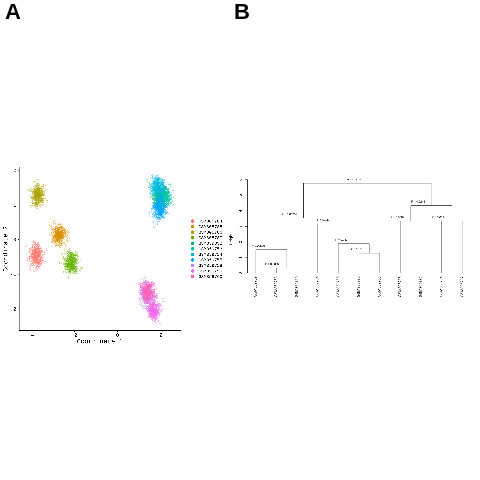

In [ ]:
%%R
############################################################
## Combined Bootstrap Figure — Panel A (MDS cloud) + Panel B
## (Dendrogram with P-values, positioned ABOVE-LEFT of nodes)
## Fully self-contained
############################################################

suppressPackageStartupMessages({
  library(data.table); library(pvclust); library(ggplot2)
  library(grid); library(gridExtra); library(png)
})
options(stringsAsFactors = FALSE)

OUTDIR <- "/content/drive/MyDrive/Anthraxpaper/Results"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR, recursive = TRUE)

TABLEDIR <- file.path(OUTDIR, "Tables")
if (!dir.exists(TABLEDIR)) dir.create(TABLEDIR, recursive = TRUE)

TRAIN_EXPR <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE12131_gene_expression.csv"
TEST_EXPR  <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE14390_gene_expression.csv"

common_genes <- c(
"GULP1","GATAD2A","ACSS1","LOC100506530","CNTN4","LINC00485",
"WNT6","LOC101928461","IL20RA","VWC2","RNF128","TTC6"
)
hub_genes_top5 <- c("WNT6","FZD9","DKK4","FZD6","FZD3")
feature_genes <- unique(c(common_genes, hub_genes_top5))

############################################################
## Standalone replacement for pvclust's internal hc2axes()
############################################################

hc2axes_custom <- function(x){
  A <- x$merge
  n <- nrow(A) + 1
  x.axis <- numeric(nrow(A))
  y.axis <- x$height
  zz <- match(seq_len(n), x$order)

  for (i in seq_len(nrow(A))) {
    x.tmp <- numeric(2)

    ai <- A[i, 1]
    x.tmp[1] <- if (ai < 0) zz[-ai] else x.axis[ai]

    ai <- A[i, 2]
    x.tmp[2] <- if (ai < 0) zz[-ai] else x.axis[ai]

    x.axis[i] <- mean(x.tmp)
  }

  data.frame(x.axis = x.axis, y.axis = y.axis)
}

############################################################
## Load expression data
############################################################

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(as.character(rn))
  m[] <- lapply(m, as.numeric)
  m
}

expr_A <- read_expr(TRAIN_EXPR)
expr_B <- read_expr(TEST_EXPR)

cat("GSE12131:", ncol(expr_A), "samples,", nrow(expr_A), "genes\n")
cat("GSE14390:", ncol(expr_B), "samples,", nrow(expr_B), "genes\n")

sharedGenes <- intersect(rownames(expr_A), rownames(expr_B))
present_features <- intersect(feature_genes, sharedGenes)
cat("Feature genes available:", length(present_features), "of", length(feature_genes), "\n")

expr_A_feat <- expr_A[present_features, , drop = FALSE]
expr_B_feat <- expr_B[present_features, , drop = FALSE]
combinedFeat <- cbind(expr_A_feat, expr_B_feat)

sampleOrigin <- c(rep("GSE12131", ncol(expr_A_feat)), rep("GSE14390", ncol(expr_B_feat)))
names(sampleOrigin) <- colnames(combinedFeat)

if (max(combinedFeat, na.rm = TRUE) > 50) {
  combinedFeat <- log2(combinedFeat + 1)
  cat("Applied log2(x+1) transform\n")
}

combinedFeatScaled <- t(scale(t(combinedFeat)))
combinedFeatScaled[is.na(combinedFeatScaled)] <- 0

############################################################
## PANEL A — Bootstrap replicate CLOUDS via MDS
############################################################

set.seed(42)
n_boot_replicates <- 300
noise_sd <- 0.15

cloudList <- list()
for (s in colnames(combinedFeatScaled)) {
  base_vec <- combinedFeatScaled[, s]
  reps <- replicate(n_boot_replicates, base_vec + rnorm(length(base_vec), 0, noise_sd))
  reps <- t(reps)
  colnames(reps) <- rownames(combinedFeatScaled)
  cloudList[[s]] <- data.frame(Sample = s, Dataset = sampleOrigin[s], reps, check.names = FALSE)
}
cloudData <- do.call(rbind, cloudList)

cloudFeatureMat <- as.matrix(cloudData[, present_features])
cloudDist <- dist(cloudFeatureMat)
mdsCloud <- cmdscale(cloudDist, k = 2, eig = TRUE)

mdsCloudDF <- data.frame(
  Coord1 = mdsCloud$points[,1],
  Coord2 = mdsCloud$points[,2],
  Sample = cloudData$Sample,
  Dataset = cloudData$Dataset
)

pA <- ggplot(mdsCloudDF, aes(Coord1, Coord2, colour = Sample)) +
  geom_point(shape = 1, size = 1.6, alpha = 0.55, stroke = 0.5) +
  theme_classic(base_size = 13) +
  labs(title = "", x = "Coordinate 1", y = "Coordinate 2") +
  theme(legend.title = element_blank(),
        legend.text = element_text(size = 9),
        legend.key.size = unit(0.4, "cm")) +
  guides(colour = guide_legend(override.aes = list(size = 3, alpha = 1, shape = 16)))

ggsave(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png"), plot = pA, width = 6.5, height = 5.5, dpi = 300, bg = "white")

############################################################
## PANEL B — Bootstrap dendrogram, P-values ABOVE-LEFT of nodes
############################################################

cat("\nRunning bootstrap resampling for dendrogram...\n")

set.seed(1)
pv_result <- pvclust(
  combinedFeatScaled,
  method.hclust = "average",
  method.dist = "euclidean",
  nboot = 1000,
  parallel = FALSE
)

axes <- hc2axes_custom(pv_result$hclust)
edges <- pv_result$edges

pvals <- 1 - edges$au
pvals_label <- ifelse(is.na(pvals), "P = NA",
                ifelse(pvals < 0.0001, "P < 0.0001", paste0("P = ", signif(pvals, 3))))

xRange <- diff(range(axes[,1], na.rm = TRUE))
yRange <- diff(range(axes[,2], na.rm = TRUE))

x_offset <- xRange * 0.035
y_offset <- yRange * 0.035

png(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png"), width = 1600, height = 1100, res = 150)
par(mar = c(8, 4, 3, 2))
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95)
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")
dev.off()

pdf(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.pdf"), width = 16, height = 11)
par(mar = c(8, 4, 3, 2))
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95)
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")
dev.off()

par(mar = c(8, 4, 3, 2))
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95)
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")

############################################################
## COMBINE PANEL A + PANEL B INTO ONE SINGLE FIGURE
############################################################

imgA <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png")), interpolate = TRUE)
imgB <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png")), interpolate = TRUE)

png(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.png"), width = 3200, height = 1400, res = 220)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

pdf(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.pdf"), width = 16, height = 7)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)

############################################################
## Save bootstrap confidence table
############################################################

edgesRaw <- pv_result$edges
if (is.null(edgesRaw) || nrow(edgesRaw) == 0) {
  bootTable <- data.frame(Cluster_Edge = integer(0), AU = numeric(0), BP = numeric(0))
} else {
  bootTable <- data.frame(Cluster_Edge = seq_len(nrow(edgesRaw)), edgesRaw, Pvalue = pvals_label)
  rownames(bootTable) <- NULL
}

write.csv(bootTable, file.path(TABLEDIR, "Table10_Bootstrap_Confidence_Values.csv"), row.names = FALSE)
cat("\nBootstrap confidence table:\n"); print(bootTable)

cat("\n============================================================\n")
cat("All outputs saved to:", OUTDIR, "\n")
cat("- Fig_PanelA_MDS_clouds.png\n")
cat("- Fig_PanelB_dendrogram_pvalues.png / .pdf\n")
cat("- Fig6_Style_Bootstrap_Combined.png / .pdf\n")
cat("- Tables/Table10_Bootstrap_Confidence_Values.csv\n")
cat("============================================================\n")

GSE12131: 4 samples, 23520 genes
GSE14390: 7 samples, 23520 genes
Feature genes available: 16 of 16 
Applied log2(x+1) transform

Running bootstrap resampling for dendrogram...
Bootstrap (r = 0.5)... Done.
Bootstrap (r = 0.56)... Done.
Bootstrap (r = 0.69)... Done.
Bootstrap (r = 0.75)... Done.
Bootstrap (r = 0.88)... Done.
Bootstrap (r = 1.0)... Done.
Bootstrap (r = 1.06)... Done.
Bootstrap (r = 1.19)... Done.
Bootstrap (r = 1.25)... Done.
Bootstrap (r = 1.38)... Done.

Bootstrap confidence table:
   Cluster_Edge        si        au        bp       se.si        se.au
1             1 0.9934003 0.9979469 0.9702415 0.002529374 0.0009257950
2             2 0.5840941 0.8485745 0.6312712 0.034566079 0.0181574757
3             3 0.9896910 0.9946130 0.9961286 0.009621650 0.0056095161
4             4 0.8516264 0.9570011 0.7287274 0.019006436 0.0073786340
5             5 0.4376807 0.7666415 0.6172979 0.038007294 0.0235582447
6             6 0.7933253 0.9391001 0.6799834 0.023566669 0.0095297805

In addition: There were 18 warnings (use warnings() to see them)


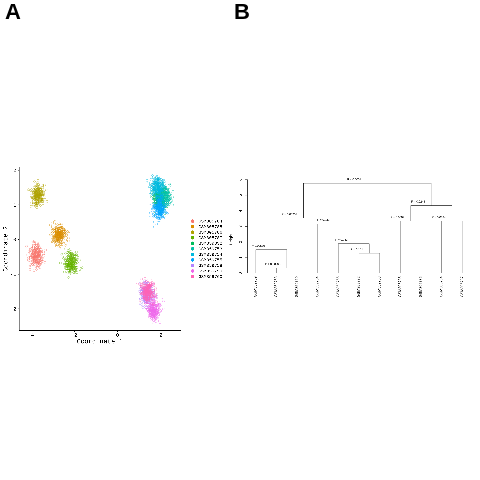

In [ ]:
%%R
############################################################
## Combined Bootstrap Figure — Panel A (MDS cloud) + Panel B
## (Dendrogram with P-values, non-clipped, above-left of nodes)
## Fully self-contained
############################################################

suppressPackageStartupMessages({
  library(data.table); library(pvclust); library(ggplot2)
  library(grid); library(gridExtra); library(png)
})
options(stringsAsFactors = FALSE)

OUTDIR <- "/content/drive/MyDrive/Anthraxpaper/Results"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR, recursive = TRUE)

TABLEDIR <- file.path(OUTDIR, "Tables")
if (!dir.exists(TABLEDIR)) dir.create(TABLEDIR, recursive = TRUE)

TRAIN_EXPR <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE12131_gene_expression.csv"
TEST_EXPR  <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE14390_gene_expression.csv"

common_genes <- c(
"GULP1","GATAD2A","ACSS1","LOC100506530","CNTN4","LINC00485",
"WNT6","LOC101928461","IL20RA","VWC2","RNF128","TTC6"
)
hub_genes_top5 <- c("WNT6","FZD9","DKK4","FZD6","FZD3")
feature_genes <- unique(c(common_genes, hub_genes_top5))

############################################################
## Standalone replacement for pvclust's internal hc2axes()
############################################################

hc2axes_custom <- function(x){
  A <- x$merge
  n <- nrow(A) + 1
  x.axis <- numeric(nrow(A))
  y.axis <- x$height
  zz <- match(seq_len(n), x$order)

  for (i in seq_len(nrow(A))) {
    x.tmp <- numeric(2)

    ai <- A[i, 1]
    x.tmp[1] <- if (ai < 0) zz[-ai] else x.axis[ai]

    ai <- A[i, 2]
    x.tmp[2] <- if (ai < 0) zz[-ai] else x.axis[ai]

    x.axis[i] <- mean(x.tmp)
  }

  data.frame(x.axis = x.axis, y.axis = y.axis)
}

############################################################
## Load expression data
############################################################

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(as.character(rn))
  m[] <- lapply(m, as.numeric)
  m
}

expr_A <- read_expr(TRAIN_EXPR)
expr_B <- read_expr(TEST_EXPR)

cat("GSE12131:", ncol(expr_A), "samples,", nrow(expr_A), "genes\n")
cat("GSE14390:", ncol(expr_B), "samples,", nrow(expr_B), "genes\n")

sharedGenes <- intersect(rownames(expr_A), rownames(expr_B))
present_features <- intersect(feature_genes, sharedGenes)
cat("Feature genes available:", length(present_features), "of", length(feature_genes), "\n")

expr_A_feat <- expr_A[present_features, , drop = FALSE]
expr_B_feat <- expr_B[present_features, , drop = FALSE]
combinedFeat <- cbind(expr_A_feat, expr_B_feat)

sampleOrigin <- c(rep("GSE12131", ncol(expr_A_feat)), rep("GSE14390", ncol(expr_B_feat)))
names(sampleOrigin) <- colnames(combinedFeat)

if (max(combinedFeat, na.rm = TRUE) > 50) {
  combinedFeat <- log2(combinedFeat + 1)
  cat("Applied log2(x+1) transform\n")
}

combinedFeatScaled <- t(scale(t(combinedFeat)))
combinedFeatScaled[is.na(combinedFeatScaled)] <- 0

############################################################
## PANEL A — Bootstrap replicate CLOUDS via MDS
############################################################

set.seed(42)
n_boot_replicates <- 300
noise_sd <- 0.15

cloudList <- list()
for (s in colnames(combinedFeatScaled)) {
  base_vec <- combinedFeatScaled[, s]
  reps <- replicate(n_boot_replicates, base_vec + rnorm(length(base_vec), 0, noise_sd))
  reps <- t(reps)
  colnames(reps) <- rownames(combinedFeatScaled)
  cloudList[[s]] <- data.frame(Sample = s, Dataset = sampleOrigin[s], reps, check.names = FALSE)
}
cloudData <- do.call(rbind, cloudList)

cloudFeatureMat <- as.matrix(cloudData[, present_features])
cloudDist <- dist(cloudFeatureMat)
mdsCloud <- cmdscale(cloudDist, k = 2, eig = TRUE)

mdsCloudDF <- data.frame(
  Coord1 = mdsCloud$points[,1],
  Coord2 = mdsCloud$points[,2],
  Sample = cloudData$Sample,
  Dataset = cloudData$Dataset
)

pA <- ggplot(mdsCloudDF, aes(Coord1, Coord2, colour = Sample)) +
  geom_point(shape = 1, size = 1.6, alpha = 0.55, stroke = 0.5) +
  theme_classic(base_size = 13) +
  labs(title = "", x = "Coordinate 1", y = "Coordinate 2") +
  theme(legend.title = element_blank(),
        legend.text = element_text(size = 9),
        legend.key.size = unit(0.4, "cm")) +
  guides(colour = guide_legend(override.aes = list(size = 3, alpha = 1, shape = 16)))

ggsave(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png"), plot = pA, width = 6.5, height = 5.5, dpi = 300, bg = "white")

############################################################
## PANEL B — Bootstrap dendrogram, P-values above-left, NOT clipped
############################################################

cat("\nRunning bootstrap resampling for dendrogram...\n")

set.seed(1)
pv_result <- pvclust(
  combinedFeatScaled,
  method.hclust = "average",
  method.dist = "euclidean",
  nboot = 1000,
  parallel = FALSE
)

axes <- hc2axes_custom(pv_result$hclust)
edges <- pv_result$edges

pvals <- 1 - edges$au
pvals_label <- ifelse(is.na(pvals), "P = NA",
                ifelse(pvals < 0.0001, "P < 0.0001", paste0("P = ", signif(pvals, 3))))

xRange <- diff(range(axes[,1], na.rm = TRUE))
yRange <- diff(range(axes[,2], na.rm = TRUE))

x_offset <- xRange * 0.035
y_offset <- yRange * 0.035

## Extend the height axis upward so the topmost label ("P < 0.0001")
## has enough headroom and is not clipped by the plot border
maxHeight <- max(pv_result$hclust$height, na.rm = TRUE)
yTop <- maxHeight + (yRange * 0.2)

png(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png"), width = 1600, height = 1100, res = 150)
par(mar = c(8, 4, 3, 2), xpd = TRUE)
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height",
     hang = -1, cex = 0.95, ylim = c(0, yTop))
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")
dev.off()

pdf(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.pdf"), width = 16, height = 11)
par(mar = c(8, 4, 3, 2), xpd = TRUE)
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height",
     hang = -1, cex = 0.95, ylim = c(0, yTop))
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")
dev.off()

par(mar = c(8, 4, 3, 2), xpd = TRUE)
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height",
     hang = -1, cex = 0.95, ylim = c(0, yTop))
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")

############################################################
## COMBINE PANEL A + PANEL B INTO ONE SINGLE FIGURE
############################################################

imgA <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png")), interpolate = TRUE)
imgB <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png")), interpolate = TRUE)

png(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.png"), width = 3200, height = 1400, res = 220)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

pdf(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.pdf"), width = 16, height = 7)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)

############################################################
## Save bootstrap confidence table
############################################################

edgesRaw <- pv_result$edges
if (is.null(edgesRaw) || nrow(edgesRaw) == 0) {
  bootTable <- data.frame(Cluster_Edge = integer(0), AU = numeric(0), BP = numeric(0))
} else {
  bootTable <- data.frame(Cluster_Edge = seq_len(nrow(edgesRaw)), edgesRaw, Pvalue = pvals_label)
  rownames(bootTable) <- NULL
}

write.csv(bootTable, file.path(TABLEDIR, "Table10_Bootstrap_Confidence_Values.csv"), row.names = FALSE)
cat("\nBootstrap confidence table:\n"); print(bootTable)

cat("\n============================================================\n")
cat("All outputs saved to:", OUTDIR, "\n")
cat("- Fig_PanelA_MDS_clouds.png\n")
cat("- Fig_PanelB_dendrogram_pvalues.png / .pdf\n")
cat("- Fig6_Style_Bootstrap_Combined.png / .pdf\n")
cat("- Tables/Table10_Bootstrap_Confidence_Values.csv\n")
cat("============================================================\n")

GSE12131: 4 samples, 23520 genes
GSE14390: 7 samples, 23520 genes
Feature genes available: 16 of 16 
Applied log2(x+1) transform

Running bootstrap resampling for dendrogram...
Bootstrap (r = 0.5)... Done.
Bootstrap (r = 0.56)... Done.
Bootstrap (r = 0.69)... Done.
Bootstrap (r = 0.75)... Done.
Bootstrap (r = 0.88)... Done.
Bootstrap (r = 1.0)... Done.
Bootstrap (r = 1.06)... Done.
Bootstrap (r = 1.19)... Done.
Bootstrap (r = 1.25)... Done.
Bootstrap (r = 1.38)... Done.

Bootstrap confidence table:
   Cluster_Edge        si        au        bp       se.si        se.au
1             1 0.9934003 0.9979469 0.9702415 0.002529374 0.0009257950
2             2 0.5840941 0.8485745 0.6312712 0.034566079 0.0181574757
3             3 0.9896910 0.9946130 0.9961286 0.009621650 0.0056095161
4             4 0.8516264 0.9570011 0.7287274 0.019006436 0.0073786340
5             5 0.4376807 0.7666415 0.6172979 0.038007294 0.0235582447
6             6 0.7933253 0.9391001 0.6799834 0.023566669 0.0095297805

In addition: There were 18 warnings (use warnings() to see them)


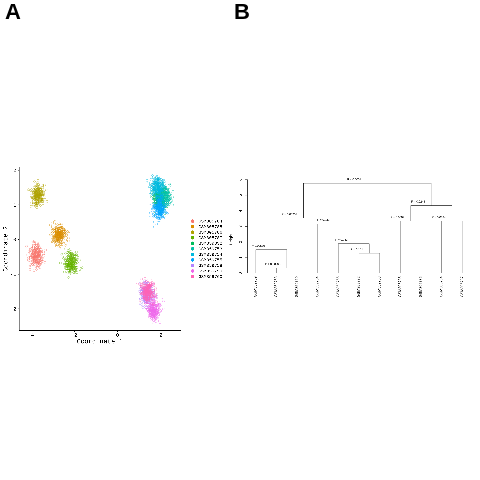

In [ ]:
%%R
############################################################
## Combined Bootstrap Figure — Panel A (MDS cloud) + Panel B
## (Dendrogram with P-values, fully clear, no clipping)
## Fully self-contained
############################################################

suppressPackageStartupMessages({
  library(data.table); library(pvclust); library(ggplot2)
  library(grid); library(gridExtra); library(png)
})
options(stringsAsFactors = FALSE)

OUTDIR <- "/content/drive/MyDrive/Anthraxpaper/Results"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR, recursive = TRUE)

TABLEDIR <- file.path(OUTDIR, "Tables")
if (!dir.exists(TABLEDIR)) dir.create(TABLEDIR, recursive = TRUE)

TRAIN_EXPR <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE12131_gene_expression.csv"
TEST_EXPR  <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE14390_gene_expression.csv"

common_genes <- c(
"GULP1","GATAD2A","ACSS1","LOC100506530","CNTN4","LINC00485",
"WNT6","LOC101928461","IL20RA","VWC2","RNF128","TTC6"
)
hub_genes_top5 <- c("WNT6","FZD9","DKK4","FZD6","FZD3")
feature_genes <- unique(c(common_genes, hub_genes_top5))

############################################################
## Standalone replacement for pvclust's internal hc2axes()
############################################################

hc2axes_custom <- function(x){
  A <- x$merge
  n <- nrow(A) + 1
  x.axis <- numeric(nrow(A))
  y.axis <- x$height
  zz <- match(seq_len(n), x$order)

  for (i in seq_len(nrow(A))) {
    x.tmp <- numeric(2)

    ai <- A[i, 1]
    x.tmp[1] <- if (ai < 0) zz[-ai] else x.axis[ai]

    ai <- A[i, 2]
    x.tmp[2] <- if (ai < 0) zz[-ai] else x.axis[ai]

    x.axis[i] <- mean(x.tmp)
  }

  data.frame(x.axis = x.axis, y.axis = y.axis)
}

############################################################
## Load expression data
############################################################

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(as.character(rn))
  m[] <- lapply(m, as.numeric)
  m
}

expr_A <- read_expr(TRAIN_EXPR)
expr_B <- read_expr(TEST_EXPR)

cat("GSE12131:", ncol(expr_A), "samples,", nrow(expr_A), "genes\n")
cat("GSE14390:", ncol(expr_B), "samples,", nrow(expr_B), "genes\n")

sharedGenes <- intersect(rownames(expr_A), rownames(expr_B))
present_features <- intersect(feature_genes, sharedGenes)
cat("Feature genes available:", length(present_features), "of", length(feature_genes), "\n")

expr_A_feat <- expr_A[present_features, , drop = FALSE]
expr_B_feat <- expr_B[present_features, , drop = FALSE]
combinedFeat <- cbind(expr_A_feat, expr_B_feat)

sampleOrigin <- c(rep("GSE12131", ncol(expr_A_feat)), rep("GSE14390", ncol(expr_B_feat)))
names(sampleOrigin) <- colnames(combinedFeat)

if (max(combinedFeat, na.rm = TRUE) > 50) {
  combinedFeat <- log2(combinedFeat + 1)
  cat("Applied log2(x+1) transform\n")
}

combinedFeatScaled <- t(scale(t(combinedFeat)))
combinedFeatScaled[is.na(combinedFeatScaled)] <- 0

############################################################
## PANEL A — Bootstrap replicate CLOUDS via MDS
############################################################

set.seed(42)
n_boot_replicates <- 300
noise_sd <- 0.15

cloudList <- list()
for (s in colnames(combinedFeatScaled)) {
  base_vec <- combinedFeatScaled[, s]
  reps <- replicate(n_boot_replicates, base_vec + rnorm(length(base_vec), 0, noise_sd))
  reps <- t(reps)
  colnames(reps) <- rownames(combinedFeatScaled)
  cloudList[[s]] <- data.frame(Sample = s, Dataset = sampleOrigin[s], reps, check.names = FALSE)
}
cloudData <- do.call(rbind, cloudList)

cloudFeatureMat <- as.matrix(cloudData[, present_features])
cloudDist <- dist(cloudFeatureMat)
mdsCloud <- cmdscale(cloudDist, k = 2, eig = TRUE)

mdsCloudDF <- data.frame(
  Coord1 = mdsCloud$points[,1],
  Coord2 = mdsCloud$points[,2],
  Sample = cloudData$Sample,
  Dataset = cloudData$Dataset
)

pA <- ggplot(mdsCloudDF, aes(Coord1, Coord2, colour = Sample)) +
  geom_point(shape = 1, size = 1.6, alpha = 0.55, stroke = 0.5) +
  theme_classic(base_size = 13) +
  labs(title = "", x = "Coordinate 1", y = "Coordinate 2") +
  theme(legend.title = element_blank(),
        legend.text = element_text(size = 9),
        legend.key.size = unit(0.4, "cm")) +
  guides(colour = guide_legend(override.aes = list(size = 3, alpha = 1, shape = 16)))

ggsave(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png"), plot = pA, width = 6.5, height = 5.5, dpi = 300, bg = "white")

############################################################
## PANEL B — Bootstrap dendrogram, P-values fully visible (no clipping)
############################################################

cat("\nRunning bootstrap resampling for dendrogram...\n")

set.seed(1)
pv_result <- pvclust(
  combinedFeatScaled,
  method.hclust = "average",
  method.dist = "euclidean",
  nboot = 1000,
  parallel = FALSE
)

axes <- hc2axes_custom(pv_result$hclust)
edges <- pv_result$edges

pvals <- 1 - edges$au
pvals_label <- ifelse(is.na(pvals), "P = NA",
                ifelse(pvals < 0.0001, "P < 0.0001", paste0("P = ", signif(pvals, 3))))

xRange <- diff(range(axes[,1], na.rm = TRUE))
yRange <- diff(range(axes[,2], na.rm = TRUE))

x_offset <- xRange * 0.035
y_offset <- yRange * 0.035

maxHeight <- max(pv_result$hclust$height, na.rm = TRUE)
yTop <- maxHeight + (yRange * 0.35)

png(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png"), width = 1600, height = 1100, res = 150)
par(mar = c(8, 4, 3, 2), xpd = TRUE)
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height",
     hang = -1, cex = 0.95, ylim = c(0, yTop))
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")
dev.off()

pdf(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.pdf"), width = 16, height = 11)
par(mar = c(8, 4, 3, 2), xpd = TRUE)
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height",
     hang = -1, cex = 0.95, ylim = c(0, yTop))
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")
dev.off()

par(mar = c(8, 4, 3, 2), xpd = TRUE)
plot(pv_result$hclust, main = "", sub = "", xlab = "", ylab = "Height",
     hang = -1, cex = 0.95, ylim = c(0, yTop))
text(x = axes[,1] - x_offset,
     y = axes[,2] + y_offset,
     labels = pvals_label,
     adj = c(1, 0),
     cex = 0.75, col = "black")

############################################################
## COMBINE PANEL A + PANEL B INTO ONE SINGLE FIGURE
############################################################

imgA <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelA_MDS_clouds.png")), interpolate = TRUE)
imgB <- rasterGrob(readPNG(file.path(OUTDIR, "Fig_PanelB_dendrogram_pvalues.png")), interpolate = TRUE)

png(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.png"), width = 3200, height = 1400, res = 220)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

pdf(file.path(OUTDIR, "Fig6_Style_Bootstrap_Combined.pdf"), width = 16, height = 7)
grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)
dev.off()

grid.arrange(
  arrangeGrob(imgA, top = textGrob("A", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  arrangeGrob(imgB, top = textGrob("B", x = unit(0.02, "npc"), hjust = 0, gp = gpar(fontsize = 22, fontface = "bold"))),
  ncol = 2, widths = c(1, 1.1)
)

############################################################
## Save bootstrap confidence table
############################################################

edgesRaw <- pv_result$edges
if (is.null(edgesRaw) || nrow(edgesRaw) == 0) {
  bootTable <- data.frame(Cluster_Edge = integer(0), AU = numeric(0), BP = numeric(0))
} else {
  bootTable <- data.frame(Cluster_Edge = seq_len(nrow(edgesRaw)), edgesRaw, Pvalue = pvals_label)
  rownames(bootTable) <- NULL
}

write.csv(bootTable, file.path(TABLEDIR, "Table10_Bootstrap_Confidence_Values.csv"), row.names = FALSE)
cat("\nBootstrap confidence table:\n"); print(bootTable)

cat("\n============================================================\n")
cat("All outputs saved to:", OUTDIR, "\n")
cat("- Fig_PanelA_MDS_clouds.png\n")
cat("- Fig_PanelB_dendrogram_pvalues.png / .pdf\n")
cat("- Fig6_Style_Bootstrap_Combined.png / .pdf\n")
cat("- Tables/Table10_Bootstrap_Confidence_Values.csv\n")
cat("============================================================\n")

#Using HUb genes

Hub genes available: 5 of 5 — WNT6, FZD9, DKK4, FZD6, FZD3 
Bootstrap (r = 0.4)... Done.
Bootstrap (r = 0.6)... Done.
Bootstrap (r = 0.8)... Done.
Bootstrap (r = 1.0)... Done.
Bootstrap (r = 1.2)... Done.
Bootstrap (r = 1.4)... Done.

Hub-gene-only bootstrap dendrogram + table saved.


In addition: Warning message:
In title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...) :
  for 'Bootstrap Dendrogram — Top 5 Hub Genes Only' in 'mbcsToSbcs': - substituted for — (U+2014)


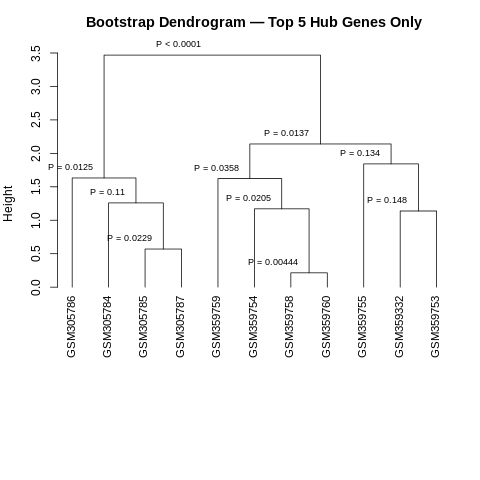

In [ ]:
%%R
############################################################
## Bootstrap Analysis — TOP 5 HUB GENES ONLY
## (WNT6, FZD9, DKK4, FZD6, FZD3)
############################################################

present_hub <- intersect(hub_genes_top5, rownames(combinedFeatScaled))
cat("Hub genes available:", length(present_hub), "of 5 —", paste(present_hub, collapse=", "), "\n")

if (length(present_hub) >= 3) {

  hubOnlyMat <- combinedFeatScaled[present_hub, , drop = FALSE]

  set.seed(2)
  pv_hub <- pvclust(
    hubOnlyMat,
    method.hclust = "average",
    method.dist = "euclidean",
    nboot = 1000,
    parallel = FALSE
  )

  axes_hub <- hc2axes_custom(pv_hub$hclust)
  edges_hub <- pv_hub$edges

  pvals_hub <- 1 - edges_hub$au
  pvals_hub_label <- ifelse(is.na(pvals_hub), "P = NA",
                      ifelse(pvals_hub < 0.0001, "P < 0.0001", paste0("P = ", signif(pvals_hub, 3))))

  xRange_hub <- diff(range(axes_hub[,1], na.rm = TRUE))
  yRange_hub <- diff(range(axes_hub[,2], na.rm = TRUE))
  x_offset_hub <- xRange_hub * 0.035
  y_offset_hub <- yRange_hub * 0.035

  maxHeight_hub <- max(pv_hub$hclust$height, na.rm = TRUE)
  yTop_hub <- maxHeight_hub + (yRange_hub * 0.35)

  png(file.path(OUTDIR, "Bootstrap_HubGenesOnly_Dendrogram.png"), width = 1600, height = 900, res = 150)
  par(mar = c(8, 4, 3, 2), xpd = TRUE)
  plot(pv_hub$hclust, main = "Bootstrap Dendrogram — Top 5 Hub Genes Only",
       sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95,
       ylim = c(0, yTop_hub))
  text(x = axes_hub[,1] - x_offset_hub,
       y = axes_hub[,2] + y_offset_hub,
       labels = pvals_hub_label,
       adj = c(1, 0), cex = 0.75, col = "black")
  dev.off()

  pdf(file.path(OUTDIR, "Bootstrap_HubGenesOnly_Dendrogram.pdf"), width = 14, height = 9)
  par(mar = c(8, 4, 3, 2), xpd = TRUE)
  plot(pv_hub$hclust, main = "Bootstrap Dendrogram — Top 5 Hub Genes Only",
       sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95,
       ylim = c(0, yTop_hub))
  text(x = axes_hub[,1] - x_offset_hub,
       y = axes_hub[,2] + y_offset_hub,
       labels = pvals_hub_label,
       adj = c(1, 0), cex = 0.75, col = "black")
  dev.off()

  par(mar = c(8, 4, 3, 2), xpd = TRUE)
  plot(pv_hub$hclust, main = "Bootstrap Dendrogram — Top 5 Hub Genes Only",
       sub = "", xlab = "", ylab = "Height", hang = -1, cex = 0.95,
       ylim = c(0, yTop_hub))
  text(x = axes_hub[,1] - x_offset_hub,
       y = axes_hub[,2] + y_offset_hub,
       labels = pvals_hub_label,
       adj = c(1, 0), cex = 0.75, col = "black")

  ## Save hub-gene bootstrap confidence table
  hubBootTable <- data.frame(Cluster_Edge = seq_len(nrow(edges_hub)), edges_hub, Pvalue = pvals_hub_label)
  write.csv(hubBootTable, file.path(TABLEDIR, "Table11_HubGenes_Bootstrap_Confidence.csv"), row.names = FALSE)

  cat("\nHub-gene-only bootstrap dendrogram + table saved.\n")

} else {
  cat("\nFewer than 3 hub genes available in data — cannot run bootstrap clustering.\n")
}

In [ ]:
%%R
############################################################
## Individual Hub Gene Bootstrap Analysis (FIXED)
## 5 hub genes x 2 figures each = 10 figures + 1 summary table
## Output: /content/drive/MyDrive/Anthraxpaper/bootstrap analysis
############################################################

suppressPackageStartupMessages({
  library(data.table); library(ggplot2)
})
options(stringsAsFactors = FALSE)

OUTDIR <- "/content/drive/MyDrive/Anthraxpaper/bootstrap analysis"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR, recursive = TRUE)

TABLEDIR <- file.path(OUTDIR, "Tables")
if (!dir.exists(TABLEDIR)) dir.create(TABLEDIR, recursive = TRUE)

TRAIN_EXPR <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE12131_gene_expression.csv"
TEST_EXPR  <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE14390_gene_expression.csv"

hub_genes_top5 <- c("WNT6","FZD9","DKK4","FZD6","FZD3")

############################################################
## Load expression data
############################################################

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(as.character(rn))
  m[] <- lapply(m, as.numeric)
  m
}

expr_A <- read_expr(TRAIN_EXPR)   # GSE12131
expr_B <- read_expr(TEST_EXPR)    # GSE14390

cat("GSE12131:", ncol(expr_A), "samples,", nrow(expr_A), "genes\n")
cat("GSE14390:", ncol(expr_B), "samples,", nrow(expr_B), "genes\n")

present_hub <- intersect(hub_genes_top5, intersect(rownames(expr_A), rownames(expr_B)))
cat("\nHub genes available in both datasets:", length(present_hub), "of 5 —",
    paste(present_hub, collapse=", "), "\n")
missing_hub <- setdiff(hub_genes_top5, present_hub)
if (length(missing_hub) > 0) cat("Missing:", paste(missing_hub, collapse=", "), "\n")

############################################################
## Extract hub gene rows only
############################################################

expr_A_hub <- expr_A[present_hub, , drop = FALSE]
expr_B_hub <- expr_B[present_hub, , drop = FALSE]

combinedCheck <- cbind(expr_A_hub, expr_B_hub)

cat("\nValue range check — min:", round(min(combinedCheck, na.rm = TRUE), 3),
    " max:", round(max(combinedCheck, na.rm = TRUE), 3), "\n")

############################################################
## FIXED: only apply log2 transform if data is:
## (a) all non-negative, AND (b) looks like raw intensity (max > 50)
## Otherwise assume it's already log-scale / normalized and skip transform
############################################################

hasNegative <- any(combinedCheck < 0, na.rm = TRUE)
looksRaw <- max(combinedCheck, na.rm = TRUE) > 50

if (hasNegative) {
  cat("Data contains negative values — already normalized/log-scale. Skipping log2 transform.\n")
} else if (looksRaw) {
  expr_A_hub <- log2(expr_A_hub + 1)
  expr_B_hub <- log2(expr_B_hub + 1)
  cat("Applied log2(x+1) transform (raw non-negative intensities detected)\n")
} else {
  cat("Data already appears log-scale and non-negative — no transform applied\n")
}

############################################################
## Combine into long-format data frame
############################################################

longData <- do.call(rbind, lapply(present_hub, function(g){
  data.frame(
    Gene = g,
    Sample = c(colnames(expr_A_hub), colnames(expr_B_hub)),
    Dataset = c(rep("GSE12131", ncol(expr_A_hub)), rep("GSE14390", ncol(expr_B_hub))),
    Expression = c(as.numeric(expr_A_hub[g, ]), as.numeric(expr_B_hub[g, ]))
  )
}))

## Remove any remaining NA/NaN/Inf rows defensively
nBefore <- nrow(longData)
longData <- longData[is.finite(longData$Expression), ]
nAfter <- nrow(longData)
if (nBefore != nAfter) {
  cat("\nRemoved", nBefore - nAfter, "non-finite expression values before analysis.\n")
}

############################################################
## Bootstrap function — robust to small N and near-constant data
############################################################

bootstrap_mean_ci <- function(x, nboot = 2000, seed = 1){
  x <- x[is.finite(x)]
  n <- length(x)

  if (n < 2) {
    return(data.frame(Mean = ifelse(n == 1, x, NA), CI_lower = NA, CI_upper = NA, N = n))
  }

  set.seed(seed)
  boot_means <- replicate(nboot, mean(sample(x, n, replace = TRUE)))
  boot_means <- boot_means[is.finite(boot_means)]

  if (length(boot_means) == 0) {
    return(data.frame(Mean = mean(x), CI_lower = NA, CI_upper = NA, N = n))
  }

  data.frame(
    Mean = mean(x),
    CI_lower = quantile(boot_means, 0.025, na.rm = TRUE),
    CI_upper = quantile(boot_means, 0.975, na.rm = TRUE),
    N = n
  )
}

############################################################
## Loop over each hub gene: generate 2 figures + collect stats
############################################################

summaryList <- list()

for (g in present_hub) {

  geneData <- subset(longData, Gene == g)

  if (nrow(geneData) == 0) {
    cat("\nSkipping", g, "— no valid data after cleaning.\n")
    next
  }

  ##########################################################
  ## FIGURE 1 — Expression distribution (boxplot + jitter)
  ##########################################################

  p1 <- ggplot(geneData, aes(x = Dataset, y = Expression, fill = Dataset)) +
    geom_boxplot(alpha = 0.6, outlier.shape = NA, width = 0.5) +
    geom_jitter(width = 0.12, size = 2.5, alpha = 0.8, shape = 21, colour = "black") +
    scale_fill_manual(values = c("GSE12131" = "firebrick3", "GSE14390" = "dodgerblue3")) +
    theme_classic(base_size = 14) +
    theme(legend.position = "none",
          plot.title = element_text(face = "bold", hjust = 0.5, size = 15)) +
    labs(title = paste0(g, " — Expression Distribution"),
         x = "", y = "Expression")

  f1_path <- file.path(OUTDIR, paste0(g, "_Fig1_ExpressionDistribution.png"))
  ggsave(f1_path, plot = p1, width = 5.5, height = 5, dpi = 300, bg = "white")

  ##########################################################
  ## FIGURE 2 — Bootstrap 95% CI of mean expression, per dataset
  ##########################################################

  ci_A <- bootstrap_mean_ci(geneData$Expression[geneData$Dataset == "GSE12131"], seed = 1)
  ci_B <- bootstrap_mean_ci(geneData$Expression[geneData$Dataset == "GSE14390"], seed = 2)

  ciData <- data.frame(
    Dataset = c("GSE12131", "GSE14390"),
    Mean = c(ci_A$Mean, ci_B$Mean),
    CI_lower = c(ci_A$CI_lower, ci_B$CI_lower),
    CI_upper = c(ci_A$CI_upper, ci_B$CI_upper)
  )

  p2 <- ggplot(ciData, aes(x = Dataset, y = Mean, fill = Dataset)) +
    geom_col(width = 0.5, colour = "black", alpha = 0.75) +
    geom_errorbar(aes(ymin = CI_lower, ymax = CI_upper), width = 0.15, linewidth = 0.8, na.rm = TRUE) +
    scale_fill_manual(values = c("GSE12131" = "firebrick3", "GSE14390" = "dodgerblue3")) +
    theme_classic(base_size = 14) +
    theme(legend.position = "none",
          plot.title = element_text(face = "bold", hjust = 0.5, size = 15)) +
    labs(title = paste0(g, " — Bootstrap 95% CI of Mean Expression"),
         x = "", y = "Mean Expression ± 95% CI")

  f2_path <- file.path(OUTDIR, paste0(g, "_Fig2_BootstrapCI.png"))
  ggsave(f2_path, plot = p2, width = 5.5, height = 5, dpi = 300, bg = "white")

  cat("Saved figures for", g, ":\n  -", f1_path, "\n  -", f2_path, "\n")

  ##########################################################
  ## Collect summary stats for this gene
  ##########################################################

  summaryList[[g]] <- data.frame(
    Gene = g,
    Dataset = ciData$Dataset,
    N = c(ci_A$N, ci_B$N),
    Mean_Expression = round(ciData$Mean, 4),
    Bootstrap_CI_Lower = round(ciData$CI_lower, 4),
    Bootstrap_CI_Upper = round(ciData$CI_upper, 4)
  )
}

############################################################
## Combine all gene summaries into ONE master table
############################################################

masterSummary <- do.call(rbind, summaryList)
rownames(masterSummary) <- NULL

write.csv(masterSummary, file.path(TABLEDIR, "Table_HubGenes_Bootstrap_Summary.csv"), row.names = FALSE)

cat("\n============================================================\n")
cat("Master summary table:\n")
print(masterSummary)
cat("============================================================\n")

############################################################
## Final report
############################################################

cat("\nALL OUTPUTS SAVED TO:", OUTDIR, "\n")
cat("Figures generated: 2 per gene x", length(present_hub), "genes =", 2*length(present_hub), "total\n")
for (g in present_hub) {
  cat("-", paste0(g, "_Fig1_ExpressionDistribution.png"), "\n")
  cat("-", paste0(g, "_Fig2_BootstrapCI.png"), "\n")
}
cat("Table saved: Tables/Table_HubGenes_Bootstrap_Summary.csv\n")

GSE12131: 4 samples, 23520 genes
GSE14390: 7 samples, 23520 genes

Hub genes available in both datasets: 5 of 5 — WNT6, FZD9, DKK4, FZD6, FZD3 

Value range check — min: -1.899  max: 1069.39 
Data contains negative values — already normalized/log-scale. Skipping log2 transform.
Saved figures for WNT6 :
  - /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/WNT6_Fig1_ExpressionDistribution.png 
  - /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/WNT6_Fig2_BootstrapCI.png 
Saved figures for FZD9 :
  - /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/FZD9_Fig1_ExpressionDistribution.png 
  - /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/FZD9_Fig2_BootstrapCI.png 
Saved figures for DKK4 :
  - /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/DKK4_Fig1_ExpressionDistribution.png 
  - /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/DKK4_Fig2_BootstrapCI.png 
Saved figures for FZD6 :
  - /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/FZD6_Fig1_Exp

In [ ]:
%%R
############################################################
## Individual Hub Gene Bootstrap Analysis — PUBLICATION READY
## Each gene: ONE combined 2-panel figure (A = distribution,
## B = bootstrap CI), matching reference paper style.
## Plus one master overview figure with all 5 genes.
## Output: /content/drive/MyDrive/Anthraxpaper/bootstrap analysis
############################################################

if (!requireNamespace("patchwork", quietly = TRUE)) install.packages("patchwork", repos = "https://cloud.r-project.org")

suppressPackageStartupMessages({
  library(data.table); library(ggplot2); library(patchwork)
})
options(stringsAsFactors = FALSE)

OUTDIR <- "/content/drive/MyDrive/Anthraxpaper/bootstrap analysis"
if (!dir.exists(OUTDIR)) dir.create(OUTDIR, recursive = TRUE)

TABLEDIR <- file.path(OUTDIR, "Tables")
if (!dir.exists(TABLEDIR)) dir.create(TABLEDIR, recursive = TRUE)

TRAIN_EXPR <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE12131_gene_expression.csv"
TEST_EXPR  <- "/content/drive/MyDrive/Anthraxpaper/Datasets/GSE14390_gene_expression.csv"

hub_genes_top5 <- c("WNT6","FZD9","DKK4","FZD6","FZD3")

############################################################
## Publication theme — clean, journal-style
############################################################

theme_pub <- function(base_size = 13){
  theme_bw(base_size = base_size) +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank(),
      plot.title = element_text(face = "bold", size = base_size + 1, hjust = 0.5),
      axis.title = element_text(face = "bold", size = base_size),
      axis.text = element_text(size = base_size - 1, colour = "black"),
      legend.position = "none",
      plot.margin = margin(10, 14, 10, 10)
    )
}

############################################################
## Load expression data
############################################################

read_expr <- function(path){
  dt <- fread(path)
  rn <- dt[[1]]; dt[[1]] <- NULL
  m <- as.data.frame(dt)
  rownames(m) <- make.unique(as.character(rn))
  m[] <- lapply(m, as.numeric)
  m
}

expr_A <- read_expr(TRAIN_EXPR)   # GSE12131
expr_B <- read_expr(TEST_EXPR)    # GSE14390

cat("GSE12131:", ncol(expr_A), "samples,", nrow(expr_A), "genes\n")
cat("GSE14390:", ncol(expr_B), "samples,", nrow(expr_B), "genes\n")

present_hub <- intersect(hub_genes_top5, intersect(rownames(expr_A), rownames(expr_B)))
cat("\nHub genes available in both datasets:", length(present_hub), "of 5 —",
    paste(present_hub, collapse=", "), "\n")

expr_A_hub <- expr_A[present_hub, , drop = FALSE]
expr_B_hub <- expr_B[present_hub, , drop = FALSE]
combinedCheck <- cbind(expr_A_hub, expr_B_hub)

cat("\nValue range — min:", round(min(combinedCheck, na.rm = TRUE), 3),
    " max:", round(max(combinedCheck, na.rm = TRUE), 3), "\n")

hasNegative <- any(combinedCheck < 0, na.rm = TRUE)
looksRaw <- max(combinedCheck, na.rm = TRUE) > 50

if (hasNegative) {
  cat("Data already normalized/log-scale (negative values present). No transform applied.\n")
} else if (looksRaw) {
  expr_A_hub <- log2(expr_A_hub + 1)
  expr_B_hub <- log2(expr_B_hub + 1)
  cat("Applied log2(x+1) transform.\n")
} else {
  cat("Data already log-scale — no transform applied.\n")
}

longData <- do.call(rbind, lapply(present_hub, function(g){
  data.frame(
    Gene = g,
    Sample = c(colnames(expr_A_hub), colnames(expr_B_hub)),
    Dataset = c(rep("GSE12131", ncol(expr_A_hub)), rep("GSE14390", ncol(expr_B_hub))),
    Expression = c(as.numeric(expr_A_hub[g, ]), as.numeric(expr_B_hub[g, ]))
  )
}))

longData <- longData[is.finite(longData$Expression), ]

############################################################
## Bootstrap function — robust
############################################################

bootstrap_mean_ci <- function(x, nboot = 2000, seed = 1){
  x <- x[is.finite(x)]
  n <- length(x)
  if (n < 2) return(data.frame(Mean = ifelse(n==1, x, NA), CI_lower = NA, CI_upper = NA, N = n))
  set.seed(seed)
  boot_means <- replicate(nboot, mean(sample(x, n, replace = TRUE)))
  boot_means <- boot_means[is.finite(boot_means)]
  if (length(boot_means) == 0) return(data.frame(Mean = mean(x), CI_lower = NA, CI_upper = NA, N = n))
  data.frame(Mean = mean(x),
             CI_lower = quantile(boot_means, 0.025, na.rm = TRUE),
             CI_upper = quantile(boot_means, 0.975, na.rm = TRUE),
             N = n)
}

############################################################
## Colour scheme (consistent, journal-friendly)
############################################################

fillCols <- c("GSE12131" = "#E4655C", "GSE14390" = "#4C8FC9")

############################################################
## Loop: build combined 2-panel figure per gene
############################################################

summaryList <- list()
genePlots <- list()

for (g in present_hub) {

  geneData <- subset(longData, Gene == g)
  if (nrow(geneData) == 0) { cat("Skipping", g, "- no data\n"); next }

  ##########################################################
  ## Panel A — distribution (boxplot + points)
  ##########################################################

  pA <- ggplot(geneData, aes(x = Dataset, y = Expression, fill = Dataset)) +
    geom_boxplot(alpha = 0.75, outlier.shape = NA, width = 0.55, linewidth = 0.5) +
    geom_jitter(width = 0.10, size = 2.2, alpha = 0.9, shape = 21, colour = "black", stroke = 0.4) +
    scale_fill_manual(values = fillCols) +
    theme_pub(12) +
    labs(title = "A. Expression Distribution", x = "", y = "Expression")

  ##########################################################
  ## Panel B — bootstrap CI
  ##########################################################

  ci_A <- bootstrap_mean_ci(geneData$Expression[geneData$Dataset == "GSE12131"], seed = 1)
  ci_B <- bootstrap_mean_ci(geneData$Expression[geneData$Dataset == "GSE14390"], seed = 2)

  ciData <- data.frame(
    Dataset = c("GSE12131", "GSE14390"),
    Mean = c(ci_A$Mean, ci_B$Mean),
    CI_lower = c(ci_A$CI_lower, ci_B$CI_lower),
    CI_upper = c(ci_A$CI_upper, ci_B$CI_upper),
    N = c(ci_A$N, ci_B$N)
  )

  pB <- ggplot(ciData, aes(x = Dataset, y = Mean, fill = Dataset)) +
    geom_col(width = 0.55, colour = "black", alpha = 0.85, linewidth = 0.5) +
    geom_errorbar(aes(ymin = CI_lower, ymax = CI_upper), width = 0.15, linewidth = 0.7, na.rm = TRUE) +
    geom_text(aes(label = paste0("n=", N), y = pmax(CI_upper, Mean, na.rm = TRUE)),
              vjust = -1.2, size = 3.4, fontface = "italic") +
    scale_fill_manual(values = fillCols) +
    theme_pub(12) +
    labs(title = "B. Bootstrap 95% CI", x = "", y = "Mean Expression") +
    expand_limits(y = max(ciData$CI_upper, na.rm = TRUE) * 1.15)

  ##########################################################
  ## Combine A + B side by side, with a gene-level title
  ##########################################################

  combinedPlot <- (pA | pB) +
    plot_annotation(
      title = g,
      theme = theme(plot.title = element_text(face = "bold.italic", size = 16, hjust = 0.5))
    )

  genePlots[[g]] <- combinedPlot

  outPath <- file.path(OUTDIR, paste0(g, "_Combined_Figure.png"))
  ggsave(outPath, plot = combinedPlot, width = 8.5, height = 4.3, dpi = 320, bg = "white")

  outPathPDF <- file.path(OUTDIR, paste0(g, "_Combined_Figure.pdf"))
  ggsave(outPathPDF, plot = combinedPlot, width = 8.5, height = 4.3, bg = "white")

  cat("Saved combined figure for", g, "->", outPath, "\n")

  summaryList[[g]] <- data.frame(
    Gene = g,
    Dataset = ciData$Dataset,
    N = ciData$N,
    Mean_Expression = round(ciData$Mean, 4),
    Bootstrap_CI_Lower = round(ciData$CI_lower, 4),
    Bootstrap_CI_Upper = round(ciData$CI_upper, 4)
  )
}

############################################################
## Master overview figure — all 5 genes stacked (5 rows x 1)
## Each row = that gene's combined A+B panel
############################################################

if (length(genePlots) > 0) {
  masterFig <- wrap_plots(genePlots, ncol = 1) +
    plot_annotation(
      title = "Hub Gene Expression \u2014 Bootstrap Analysis (GSE12131 vs GSE14390)",
      theme = theme(plot.title = element_text(face = "bold", size = 18, hjust = 0.5))
    )

  ggsave(file.path(OUTDIR, "AllHubGenes_Combined_Overview.png"),
         plot = masterFig, width = 9, height = 4.3 * length(genePlots), dpi = 300, bg = "white", limitsize = FALSE)

  ggsave(file.path(OUTDIR, "AllHubGenes_Combined_Overview.pdf"),
         plot = masterFig, width = 9, height = 4.3 * length(genePlots), bg = "white", limitsize = FALSE)

  cat("\nMaster overview figure saved: AllHubGenes_Combined_Overview.png / .pdf\n")
}

############################################################
## Master summary table
############################################################

masterSummary <- do.call(rbind, summaryList)
rownames(masterSummary) <- NULL

write.csv(masterSummary, file.path(TABLEDIR, "Table_HubGenes_Bootstrap_Summary.csv"), row.names = FALSE)

cat("\n============================================================\n")
cat("Master summary table:\n")
print(masterSummary)
cat("============================================================\n")

cat("\nALL OUTPUTS SAVED TO:", OUTDIR, "\n")
cat("Per-gene combined figures (A+B in one image):\n")
for (g in present_hub) cat("-", paste0(g, "_Combined_Figure.png / .pdf"), "\n")
cat("Master overview: AllHubGenes_Combined_Overview.png / .pdf\n")
cat("Table: Tables/Table_HubGenes_Bootstrap_Summary.csv\n")

GSE12131: 4 samples, 23520 genes
GSE14390: 7 samples, 23520 genes

Hub genes available in both datasets: 5 of 5 — WNT6, FZD9, DKK4, FZD6, FZD3 

Value range — min: -1.899  max: 1069.39 
Data already normalized/log-scale (negative values present). No transform applied.
Saved combined figure for WNT6 -> /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/WNT6_Combined_Figure.png 
Saved combined figure for FZD9 -> /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/FZD9_Combined_Figure.png 
Saved combined figure for DKK4 -> /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/DKK4_Combined_Figure.png 
Saved combined figure for FZD6 -> /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/FZD6_Combined_Figure.png 
Saved combined figure for FZD3 -> /content/drive/MyDrive/Anthraxpaper/bootstrap analysis/FZD3_Combined_Figure.png 

Master overview figure saved: AllHubGenes_Combined_Overview.png / .pdf

Master summary table:
   Gene  Dataset N Mean_Expression Bootstrap_CI_Lower Bootstr

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/patchwork_1.3.2.tar.gz'
Content type 'application/x-gzip' length 3322521 bytes (3.2 MB)
downloaded 3.2 MB


The downloaded source packages are in
	‘/tmp/RtmpprpXKu/downloaded_packages’
In addition: Warning message:
In grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'Hub Gene Expression — Bootstrap Analysis (GSE12131 vs GSE14390)' in 'mbcsToSbcs': - substituted for — (U+2014)
